# 02 — Demographics and outcomes

Now that I know what's in the data (notebook 01), I want to see who's in it and what happens to them. The plan: build a single ICU-stay-level table that joins patient demographics with admission outcomes, then look at the distributions and how mortality breaks down by subgroup.

The N is small (~100 patients), so the subgroup numbers here are illustrative — but they're the same view I'll need at scale, and the code will carry over to the full MIMIC-IV.

## Setup

In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("../data")
HOSP = DATA_DIR / "hosp"
ICU = DATA_DIR / "icu"

con = duckdb.connect()
sns.set_theme(style="whitegrid", context="notebook")

## Building a stay-level table

Each row = one ICU stay, joined with patient demographics from `patients` and admission-level info (including the mortality outcome) from `admissions`.

In [2]:
query = f"""
SELECT
    i.subject_id,
    i.hadm_id,
    i.stay_id,
    i.intime,
    i.outtime,
    i.los,
    i.first_careunit,
    p.gender,
    p.anchor_age,
    a.race,
    a.insurance,
    a.marital_status,
    a.hospital_expire_flag
FROM '{ICU / 'icustays.csv.gz'}' AS i
LEFT JOIN '{HOSP / 'patients.csv.gz'}' AS p
    ON i.subject_id = p.subject_id
LEFT JOIN '{HOSP / 'admissions.csv.gz'}' AS a
    ON i.hadm_id = a.hadm_id
"""

stays = con.execute(query).df()
print(f"shape: {stays.shape}")
print(f"unique patients: {stays['subject_id'].nunique()}")
stays.head()

shape: (140, 13)
unique patients: 100


,subject_id,hadm_id,stay_id,intime,outtime,los,first_careunit,gender,anchor_age,race,insurance,marital_status,hospital_expire_flag
0,10018328,23786647,31269608,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512,Neuro Stepdown,F,83,WHITE,Other,DIVORCED,0
1,10020187,24104168,37509585,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662,Neuro Surgical Intensive Care Unit (Neuro SICU),F,63,HISPANIC/LATINO - SALVADORAN,Other,MARRIED,0
2,10020187,26842957,32554129,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685,Neuro Intermediate,F,63,HISPANIC/LATINO - SALVADORAN,Other,MARRIED,0
3,10012853,27882036,31338022,2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725,Trauma SICU (TSICU),F,91,BLACK/AFRICAN AMERICAN,Medicare,WIDOWED,0
4,10020740,25826145,32145159,2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106,Trauma SICU (TSICU),M,56,WHITE,Other,SINGLE,0


## Demographic distributions

gender
M    77
F    63
Name: count, dtype: int64


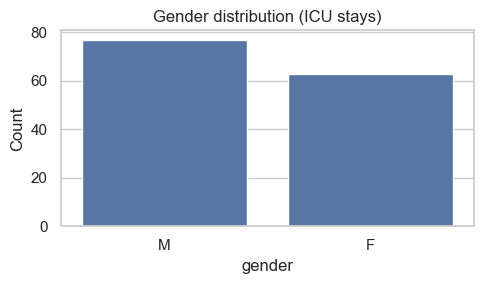

In [3]:
# Gender
gender_counts = stays["gender"].value_counts(dropna=False)
print(gender_counts)

fig, ax = plt.subplots(figsize=(5, 3))
sns.countplot(data=stays, x="gender", ax=ax, order=gender_counts.index)
ax.set_title("Gender distribution (ICU stays)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

count    140.000000
mean      62.014286
std       15.424444
min       21.000000
25%       52.000000
50%       63.000000
75%       72.000000
max       91.000000
Name: anchor_age, dtype: float64


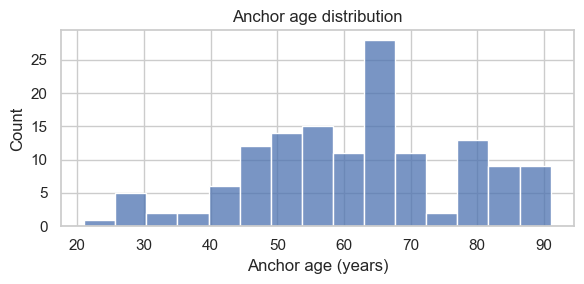

In [4]:
# Age (anchor_age)
print(stays["anchor_age"].describe())

fig, ax = plt.subplots(figsize=(6, 3))
sns.histplot(data=stays, x="anchor_age", bins=15, ax=ax)
ax.set_title("Anchor age distribution")
ax.set_xlabel("Anchor age (years)")
plt.tight_layout()
plt.show()

race
WHITE                             91
BLACK/AFRICAN AMERICAN            16
UNKNOWN                           12
OTHER                              4
HISPANIC/LATINO - SALVADORAN       3
PATIENT DECLINED TO ANSWER         3
UNABLE TO OBTAIN                   3
HISPANIC/LATINO - CUBAN            2
WHITE - BRAZILIAN                  1
BLACK/CAPE VERDEAN                 1
PORTUGUESE                         1
HISPANIC OR LATINO                 1
WHITE - OTHER EUROPEAN             1
HISPANIC/LATINO - PUERTO RICAN     1
Name: count, dtype: int64


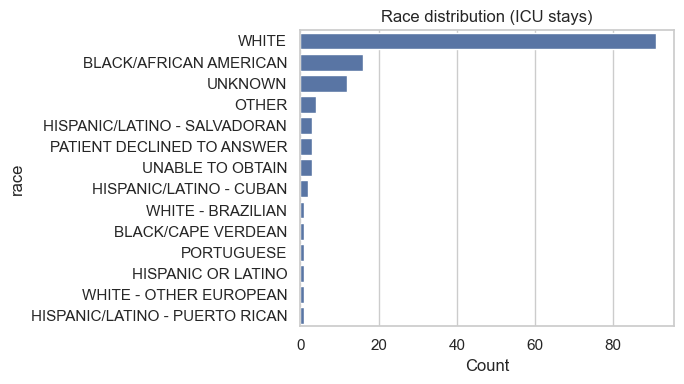

In [5]:
# Race
race_counts = stays["race"].value_counts(dropna=False)
print(race_counts)

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=stays, y="race", ax=ax, order=race_counts.index)
ax.set_title("Race distribution (ICU stays)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

The `race` field in MIMIC is self-reported and split into many sub-categories ("WHITE", "WHITE - OTHER EUROPEAN", "BLACK/AFRICAN AMERICAN", etc.), with overlaps and inconsistencies. I keep it as-is for now, but it deserves caution: race as a biological proxy is exactly the kind of category that the equity-in-clinical-AI literature critiques. For the fairness audit I'll use it as a grouping variable while being explicit about what that does and doesn't measure.

insurance
Other       74
Medicare    51
Medicaid    15
Name: count, dtype: int64


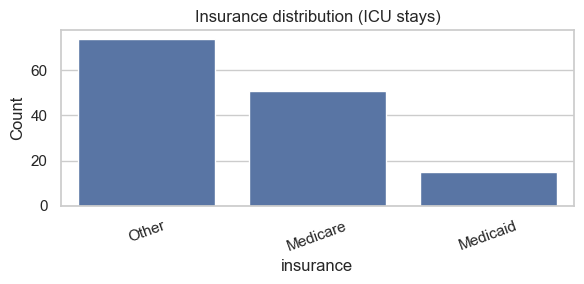

In [6]:
# Insurance
insurance_counts = stays["insurance"].value_counts(dropna=False)
print(insurance_counts)

fig, ax = plt.subplots(figsize=(6, 3))
sns.countplot(data=stays, x="insurance", ax=ax, order=insurance_counts.index)
ax.set_title("Insurance distribution (ICU stays)")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Outcome: in-hospital mortality

In [7]:
mortality_overall = stays["hospital_expire_flag"].mean()
print(f"overall in-hospital mortality rate: {mortality_overall:.1%}")
print()
print(stays["hospital_expire_flag"].value_counts())

overall in-hospital mortality rate: 14.3%

hospital_expire_flag
0    120
1     20
Name: count, dtype: int64


## Mortality stratified by subgroup

These are the subgroup rates I'll later compare with model performance. With ~100 stays the numbers will jump around a lot — read them as direction-of-effect, not as point estimates.

In [8]:
def mortality_by(group):
    return (
        stays.groupby(group, dropna=False)
        .agg(n=("hospital_expire_flag", "size"),
             deaths=("hospital_expire_flag", "sum"),
             rate=("hospital_expire_flag", "mean"))
        .sort_values("n", ascending=False)
    )

mortality_by("gender")

,n,deaths,rate
gender,,,
M,77,16,0.207792
F,63,4,0.063492


In [9]:
# Age bands
age_bins = [0, 40, 60, 75, 120]
age_labels = ["<40", "40-59", "60-74", "75+"]
stays["age_band"] = pd.cut(stays["anchor_age"], bins=age_bins, labels=age_labels, right=False)

mortality_by("age_band")

,n,deaths,rate
age_band,,,
40-59,50,3,0.060000
60-74,48,11,0.229167
75+,32,6,0.187500
<40,10,0,0.000000


In [10]:
mortality_by("race")

,n,deaths,rate
race,,,
WHITE,91,10,0.109890
BLACK/AFRICAN AMERICAN,16,2,0.125000
UNKNOWN,12,5,0.416667
OTHER,4,0,0.000000
HISPANIC/LATINO - SALVADORAN,3,0,0.000000
PATIENT DECLINED TO ANSWER,3,3,1.000000
UNABLE TO OBTAIN,3,0,0.000000
HISPANIC/LATINO - CUBAN,2,0,0.000000
BLACK/CAPE VERDEAN,1,0,0.000000


In [11]:
mortality_by("insurance")

,n,deaths,rate
insurance,,,
Other,74,5,0.067568
Medicare,51,10,0.196078
Medicaid,15,5,0.333333


## Table 1: stratified by outcome

A standard "Table 1" in clinical research compares the cohort across outcome groups. Useful as a unified view of what differs between survivors and non-survivors.

In [12]:
from tableone import TableOne

columns = ["gender", "anchor_age", "race", "insurance", "los", "first_careunit"]
categorical = ["gender", "race", "insurance", "first_careunit"]
groupby = "hospital_expire_flag"

table1 = TableOne(
    stays,
    columns=columns,
    categorical=categorical,
    groupby=groupby,
    pval=True,
)
print(table1.tabulate(tablefmt="grid"))

+-----------------------+--------------------------------------------------+-----------+-------------+-------------+-------------+-----------+
|                       |                                                  |   Missing | Overall     | 0           | 1           |   P-Value |
+=======================+==================================================+===========+=============+=============+=============+===========+
| n                     |                                                  |           | 140         | 120         | 20          |           |
+-----------------------+--------------------------------------------------+-----------+-------------+-------------+-------------+-----------+
| gender, n (%)         | F                                                |           | 63 (45.0)   | 59 (49.2)   | 4 (20.0)    |     0.029 |
+-----------------------+--------------------------------------------------+-----------+-------------+-------------+-------------+-----------+

/Users/julie/mimic-fairness-demo/.venv/lib/python3.12/site-packages/tableone/formatting.py:177: UserWarning: Order variable not found: age_band
  warnings.warn(f"Order variable not found: {k}")


## Takeaways

- I have one ICU-stay-level table with demographics + outcome, ready to be filtered into an analytic cohort.
- The N is small enough that some subgroups (specific race categories, age extremes) will have very few patients. p-values here are mostly noise.
- The `race` field will need a careful handling decision in the fairness audit — likely collapsing small categories into broader groupings, or reporting both ways.
- The mortality rate looks reasonable for ICU data; the per-subgroup rates show direction but nothing more at this sample size.

Next (notebook 03): define a clean analytic cohort — first ICU stay per patient, adults, minimum length-of-stay filter — and export it for the feature extraction step.